# Overview
The EDA phase will be split into two notebooks due to the complexity of some of the datasets.
This notebook will contain exploratory data analysis of the **Net Overseas Migration** dataset.
The analysis will go through the following phases:
1. Select the states Victoria and New South Wales to focus on for migration and their relation to the housing prices in those states.
2. Statistically and visually, prove the positive correlation between net migration to a state and its median housing prices.
3. Forecast what is likely to happen in the coming years.

# Phase 1
We will select the net migration data over the reference period for the states **Victoria (VIC)** and **New South Wales (NSW)**.
This data will be used in our time series analysis and visualisation.

### Word Dictionary
| Term | Meaning                                            |
| ----- |----------------------------------------------------|
| Arrival | The number of people entering the state/territory  |
| Departure | The number of people leaving the state/territory   |
| Total | The net number of people entering the state/territory (difference between arrival and departure) |

In [4]:
import pandas as pd

migration_data = pd.read_csv('../data/migration_data.csv')
migration_data = migration_data.iloc[:, 1:]
migration_data

,Arrival,Departure,Total,Year,State-Territory
0,75020,-39100,35920,2006,New South Wales
1,51670,-23810,27860,2006,Victoria
2,41240,-21250,19980,2006,Queensland
3,11820,-4640,7180,2006,South Australia
4,26430,-11520,14910,2006,Western Australia
...,...,...,...,...,...
295,10,-10,10,2025,Christmas Island
296,0,0,0,2025,Jervis Bay
297,0,0,0,2025,Cocos (Keeling) Islands
298,0,0,0,2025,Other Territories


In [18]:
# get the percentage change in migration from one year to the next for each city
def calculate_percentage_change(data, state):
    """
    Calculates the percentage change in net migration for the state/territory specified
    :param data: migration data
    :param state: state/territory whose percentage change in migration over the reference period is to be calculated
    :return: Series containing the percentage change in net migration over the reference period
    """
    # first sort by year in case it is not sorted
    series = data.copy()
    # isolate the data from the state we want
    series = series.loc[data['State-Territory'] == state]
    # sort by year in case it isn't
    series.sort_values(by='Year')
    # make the index of our series the time component for time series analysis
    series.index = series.pop('Year')

    # calculate percentage change
    series[state] = series['Total'].pct_change()
    return series[state]

print('SAMPLE OUTPUT:')
calculate_percentage_change(migration_data, 'Tasmania')

SAMPLE OUTPUT:


Year
2006         NaN
2007    0.837500
2008    0.421769
2009   -0.076555
2010   -0.362694
2011    0.016260
2012    0.264000
2013    0.132911
2014   -0.033520
2015   -0.184971
2016    0.617021
2017    0.127193
2018    0.233463
2019    0.252366
2020   -0.841310
2021    1.333333
2022    1.986395
2023    0.091116
2024   -0.258873
2025   -0.723944
Name: Tasmania, dtype: float64

In [37]:
states_territories = migration_data['State-Territory'].unique()
pct_migration_changes = pd.concat([calculate_percentage_change(migration_data, region) for region in states_territories], axis=1)
pct_migration_changes.index = pd.to_datetime(pct_migration_changes.index, format='%Y')
pct_migration_changes.head()

,New South Wales,Victoria,Queensland,South Australia,Western Australia,Tasmania,Northern Territory,Australian Capital Territory,Not Stated,Norfolk Island,Christmas Island,Jervis Bay,Cocos (Keeling) Islands,Other Territories,Total
Year,,,,,,,,,,,,,,,
2006-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-01,1.140869,1.385858,1.386386,0.926184,1.309188,0.837500,4.307692,1.805970,NaN,NaN,NaN,NaN,NaN,NaN,1.268569
2008-01-01,0.253966,0.252144,0.317953,0.274042,0.399651,0.421769,0.427536,0.771277,NaN,NaN,NaN,NaN,NaN,inf,0.293652
2009-01-01,-0.272426,-0.133846,-0.246817,-0.025539,-0.318531,-0.076555,-0.142132,0.102102,NaN,NaN,NaN,NaN,NaN,2.0,-0.217904
2010-01-01,-0.286773,-0.400610,-0.330868,-0.365754,-0.028624,-0.362694,-0.355030,-0.455041,NaN,NaN,NaN,NaN,NaN,-1.0,-0.303200


In [38]:
house_prices = pd.read_csv('../data/median_price_data.csv')
house_prices.index = pd.to_datetime(house_prices.pop('Quarter'))
house_prices.head()

,Median Price of Established House Transfers (Unstratified) ; Sydney ;,Median Price of Established House Transfers (Unstratified) ; Rest of NSW ;,Median Price of Established House Transfers (Unstratified) ; Melbourne ;,Median Price of Established House Transfers (Unstratified) ; Rest of Vic. ;,Median Price of Established House Transfers (Unstratified) ; Brisbane ;,Median Price of Established House Transfers (Unstratified) ; Rest of Qld. ;,Median Price of Established House Transfers (Unstratified) ; Adelaide ;,Median Price of Established House Transfers (Unstratified) ; Rest of SA ;,Median Price of Established House Transfers (Unstratified) ; Perth ;,Median Price of Established House Transfers (Unstratified) ; Rest of WA ;,...,Number of Attached Dwelling Transfers ; Rest of Qld. ;,Number of Attached Dwelling Transfers ; Adelaide ;,Number of Attached Dwelling Transfers ; Rest of SA ;,Number of Attached Dwelling Transfers ; Perth ;,Number of Attached Dwelling Transfers ; Rest of WA ;,Number of Attached Dwelling Transfers ; Hobart ;,Number of Attached Dwelling Transfers ; Rest of Tas. ;,Number of Attached Dwelling Transfers ; Darwin ;,Number of Attached Dwelling Transfers ; Rest of NT ;,Number of Attached Dwelling Transfers ; Canberra ;
Quarter,,,,,,,,,,,,,,,,,,,,,
2002-03-01,365.0,NaN,241.0,NaN,185.0,NaN,166.0,NaN,190.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-06-01,393.5,NaN,260.0,NaN,182.6,NaN,175.0,NaN,190.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-09-01,413.0,NaN,265.0,NaN,198.0,NaN,181.0,NaN,195.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-12-01,444.0,NaN,280.0,NaN,208.0,NaN,195.0,NaN,206.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-03-01,434.5,NaN,270.0,NaN,225.0,NaN,209.4,NaN,216.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
# aggregate the median prices because our migration data follows a yearly frequency instead of quarterly
house_prices_yearly = house_prices.resample('YS').mean()
house_prices_yearly = house_prices_yearly.loc[house_prices_yearly.index.year >= 2006]
pct_price_changes = house_prices_yearly.pct_change()
pct_price_changes

,Median Price of Established House Transfers (Unstratified) ; Sydney ;,Median Price of Established House Transfers (Unstratified) ; Rest of NSW ;,Median Price of Established House Transfers (Unstratified) ; Melbourne ;,Median Price of Established House Transfers (Unstratified) ; Rest of Vic. ;,Median Price of Established House Transfers (Unstratified) ; Brisbane ;,Median Price of Established House Transfers (Unstratified) ; Rest of Qld. ;,Median Price of Established House Transfers (Unstratified) ; Adelaide ;,Median Price of Established House Transfers (Unstratified) ; Rest of SA ;,Median Price of Established House Transfers (Unstratified) ; Perth ;,Median Price of Established House Transfers (Unstratified) ; Rest of WA ;,...,Median Price of Attached Dwelling Transfers (Unstratified) ; Rest of Qld. ;,Median Price of Attached Dwelling Transfers (Unstratified) ; Adelaide ;,Median Price of Attached Dwelling Transfers (Unstratified) ; Rest of SA ;,Median Price of Attached Dwelling Transfers (Unstratified) ; Perth ;,Median Price of Attached Dwelling Transfers (Unstratified) ; Rest of WA ;,Median Price of Attached Dwelling Transfers (Unstratified) ; Hobart ;,Median Price of Attached Dwelling Transfers (Unstratified) ; Rest of Tas. ;,Median Price of Attached Dwelling Transfers (Unstratified) ; Darwin ;,Median Price of Attached Dwelling Transfers (Unstratified) ; Rest of NT ;,Median Price of Attached Dwelling Transfers (Unstratified) ; Canberra ;
Quarter,,,,,,,,,,,,,,,,,,,,,
2006-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-01,0.051002,0.047619,0.076756,0.047433,0.148856,0.155997,0.135813,0.100958,0.111437,0.150230,...,0.106379,0.146934,0.112247,0.122663,0.184736,0.081967,0.065053,0.216422,0.122258,0.115065
2008-01-01,-0.041196,-0.007851,0.045730,0.015983,0.082898,0.014986,0.096725,0.066028,-0.055409,-0.022602,...,0.030943,0.106820,0.153714,-0.025783,0.018335,-0.003030,0.057402,0.077750,0.037380,0.026596
2009-01-01,0.036188,0.041233,0.076849,0.048243,0.027728,0.018658,0.031458,0.040816,0.045810,0.026603,...,-0.007980,0.038221,-0.034152,0.049716,0.062449,0.084093,0.084472,0.165236,0.310193,0.055613
2010-01-01,0.187162,0.088000,0.180233,0.126263,0.082111,0.034721,0.092035,0.088529,0.083333,0.036545,...,0.040514,0.071543,0.058001,0.079479,0.038168,0.059813,0.061283,0.115262,0.103701,0.095157
2011-01-01,-0.060700,-0.005882,-0.003441,0.034912,-0.048780,-0.022095,-0.032059,-0.031793,-0.045858,-0.030256,...,-0.058227,-0.015868,-0.005945,-0.031382,-0.052721,-0.000882,0.010254,-0.031653,0.026442,-0.002032
2012-01-01,0.073004,0.025148,-0.009393,-0.000858,-0.008547,-0.013543,-0.014013,-0.018605,0.030233,-0.001851,...,-0.023044,-0.024947,-0.089701,0.006854,-0.003105,-0.017829,-0.043269,0.029493,-0.042687,-0.007006
2013-01-01,0.101747,0.033550,0.059457,0.019330,0.033908,0.027591,0.031654,-0.029573,0.063958,0.006954,...,0.010406,0.021061,0.053723,0.074257,-0.019310,0.008986,-0.014517,0.095673,0.028538,-0.000181
2014-01-01,0.102239,0.032182,0.011321,-0.027391,0.014452,0.011691,0.031309,0.020707,-0.002122,-0.016771,...,0.032194,0.037815,0.023275,0.027650,0.025804,-0.016744,0.049632,0.041018,0.047274,-0.003619


In [ ]:
# combine the columns for the capital cities of each state the "rest of <state>" columns.


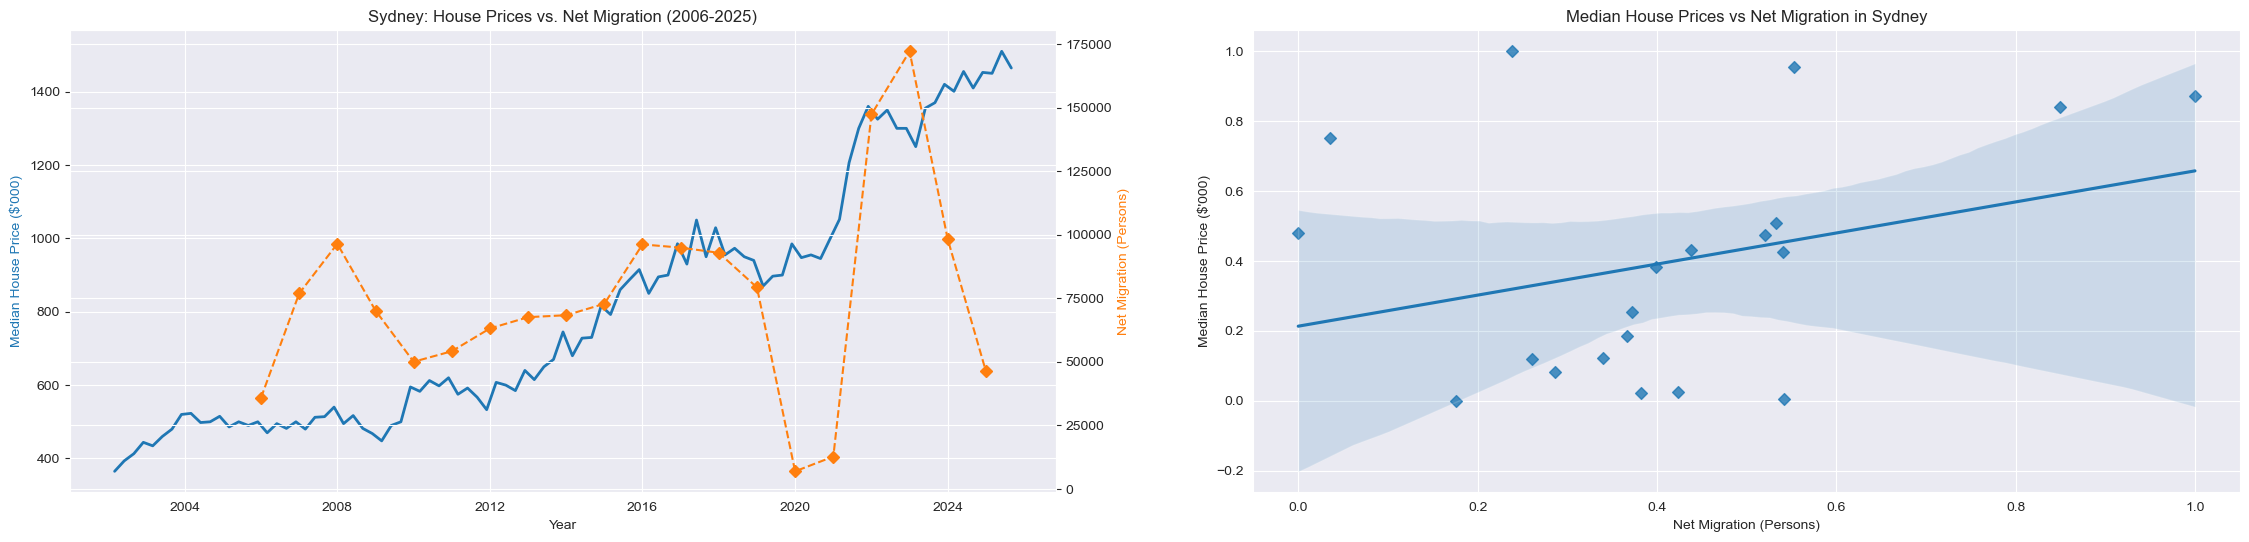

R-squared value: 0.09732481855065722


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(28, 6))

# ======= GRAPH 1 =======
# Plotting House Prices on the Left Axis
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Median House Price ($\'000)', color='tab:blue')
axes[0].plot(prices_syd.index, prices_syd, color='tab:blue', linewidth=2)

# Creating the second axis for Migration
ax2 = axes[0].twinx()
ax2.set_ylabel('Net Migration (Persons)', color='tab:orange')
ax2.plot(sydney_migration['Year'], sydney_migration['Total'], color='tab:orange', linestyle='--', marker='D')

# ======= GRAPH 2 =======
# we need to scale the two features as they are of vastly different scales at the moment. A standard min-max scaler will put all values between 0 and 1, allowing for more accurate visualisation of the correlations.
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
axes[1].set_xlabel('Net Migration (Persons)')
axes[1].set_ylabel('Median House Price ($\'000)')
axes[1].set_title('Median House Prices vs Net Migration in Sydney')
sns.regplot(x=scaler.fit_transform(sydney_migration['Total'].values.reshape(-1, 1)), y=scaler.fit_transform(prices_syd_yearly.values.reshape(-1, 1)), color='tab:blue', marker='D', ax=axes[1])
plt.title('Sydney: House Prices vs. Net Migration (2006-2025)')
plt.show()

# Calculating the R-squared value for the scatter plot to determine the statistical correlation
from sklearn.linear_model import LinearRegression
x=scaler.fit_transform(sydney_migration['Total'].values.reshape(-1, 1))
y=scaler.fit_transform(prices_syd_yearly.values.reshape(-1, 1))
model = LinearRegression()
model.fit(x, y)
r2 = model.score(x, y)
print('R-squared value:', r2)

## Key Takeaways
1. Housing prices have risen steadily over the last 20 years. This is likely simply due to Australia's chronic issue with housing supply shortages.
2. Net migration dropped steeply in 2020 and stayed low going into 2021. This is most likely due to the COVID-19 pandemic and the lockdowns that had occurred across Australia in this time period.
3. After borders had reopened, net migration skyrocketed to all-time highs due to the backlog of migrants (skilled workers, international students, temporary visa holders) waiting to enter the country.
4. This likely caused an extreme demand shock in the housing market where there was extra competition for buying houses
5. It is known that in the housing industry, it takes some time (1-3 years) for demand shocks to come into full effect for housing prices. For these reasons, Sydney's housing prices have continued to rise heading into 2025.
6. It must also be noted that net migration is not the sole reason for increasing house prices. Australia's **long standing housing supply shorage**, which has existed even prior to the pandemic, is a significant reason why housing prices are still rising. More will be discussed on this later.

## Limitations
- The main limitation with our data is the lack of more data points.
- We had to aggregate the quarterly data for the median prices so they could match the frequency of the net migration data.
- Due to the lack of data points, the confidence interval for our scatter plot is quite wide, suggesting that there is a large uncertainty in how correlated net migration is to median house prices.
- The $R^2$ value being about 0.1 (1 d.p.), in the context of government policy, suggests there is a decent relationship between net migration and median house prices.
- The positive regression line supports the theory that increased net migration does lead to increased median house prices, but should be taken with caution and skepticism due to the low suggested correlation by the $R^2=0.1$ and the fact that many other factors play a part in house prices.

# Phase 2
In this phase, we will analyse the housing supply shortages, using **Value of residential building work done** and **Value of residential building work commenced** as proxies for Australia's housing supply.

In [57]:
og_work_done = pd.read_csv('../data/work_done.csv')
work_commenced = pd.read_csv('../data/work_commenced.csv')
# initialise the index to the time column for time series analysis
og_work_done.index = pd.to_datetime(og_work_done.pop('Quarter'))
work_commenced.index = pd.to_datetime(work_commenced.pop('Quarter'))
og_work_done

,Value of work done during quarter ; Chain Volume Measures ; New South Wales ; New ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; New South Wales ; New ; Total Residential ; (SA),Value of work done during quarter ; Chain Volume Measures ; Victoria ; New ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; Victoria ; New ; Total Residential ; (SA),Value of work done during quarter ; Chain Volume Measures ; Queensland ; New ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; Queensland ; New ; Total Residential ; (SA),Value of work done during quarter ; Chain Volume Measures ; South Australia ; New ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; South Australia ; New ; Total Residential ; (SA),Value of work done during quarter ; Chain Volume Measures ; Western Australia ; New ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; Western Australia ; New ; Total Residential ; (SA),Value of work done during quarter ; Chain Volume Measures ; Tasmania ; New ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; Tasmania ; New ; Total Residential ; (SA),Value of work done during quarter ; Chain Volume Measures ; Northern Territory ; New ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; Australian Capital Territory ; New ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; Australian Capital Territory ; New ; Total Residential ; (SA)
Quarter,,,,,,,,,,,,,,,
1980-09-01,4088764,3814964,1989332,1887469,2441909,2288416,447523,429910,1128290,1090740,266348,266840,173020,134753,133871
1980-12-01,4031912,3799237,1828875,1764553,2345220,2231782,429998,410493,1018430,974481,301181,279873,159208,147704,134002
1981-03-01,3575463,3894618,1500960,1667926,2172663,2548562,371163,405729,949397,1022381,218346,240093,139579,160347,172141
1981-06-01,3844366,3882976,1626414,1591926,2551300,2447961,373040,388711,1046267,1049542,228966,226367,146849,170831,176517
1981-09-01,3910040,3649102,1672899,1591675,2953227,2775027,351760,338093,1094516,1058868,239161,239840,170476,159730,158319
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-01,6423413,6239825,7170477,6873499,4405496,4109527,1275619,1208571,1987987,1916982,252987,250093,57446,469790,455111
2024-12-01,6453399,6461590,6646086,6892943,4158744,4157601,1321422,1335900,1904090,1933378,263958,263942,61809,444827,433372
2025-03-01,6091839,6381595,6762082,7048166,4037295,4370674,1304479,1395330,1883642,1964409,246029,258923,60786,382744,423875


In [58]:
work_done = og_work_done.copy()
work_commenced

,Value of work commenced ; Chain Volume Measures ; New South Wales ; New ; Total Residential ;,Value of work commenced ; Chain Volume Measures ; Victoria ; New ; Total Residential ;,Value of work commenced ; Chain Volume Measures ; Queensland ; New ; Total Residential ;,Value of work commenced ; Chain Volume Measures ; South Australia ; New ; Total Residential ;,Value of work commenced ; Chain Volume Measures ; Western Australia ; New ; Total Residential ;,Value of work commenced ; Chain Volume Measures ; Tasmania ; New ; Total Residential ;,Value of work commenced ; Chain Volume Measures ; Northern Territory ; New ; Total Residential ;,Value of work commenced ; Chain Volume Measures ; Australian Capital Territory ; New ; Total Residential ;
Quarter,,,,,,,,
1969-09-01,3229627,2000160,1043840,514416,1232832,319555,78450,152902
1969-12-01,3003763,1909886,953878,495823,1082639,189445,67495,150166
1970-03-01,3216247,1794135,1016709,483737,1101781,231402,93292,228897
1970-06-01,2949607,1781120,980653,521854,962632,193683,86577,196371
1970-09-01,2811668,1899363,1069900,572366,921771,265731,119795,229201
...,...,...,...,...,...,...,...,...
2024-09-01,6902098,7068121,4739307,1226155,2259667,285063,35253,137798
2024-12-01,6014272,6632368,4735912,1302920,2133662,255711,60725,369587
2025-03-01,6577509,7575847,3973224,1499104,2215002,245743,81048,200633


In [59]:
print('====== INFORMATION ABOUT THE DATASETS ======')
print('== DATA TYPES ==')
print(work_done.dtypes)
print('== DATASET INDEX ==')
print(work_done.index)

====== INFORMATION ABOUT THE DATASETS ======
== DATA TYPES ==
Value of work done during quarter ;  Chain Volume Measures ;  New South Wales ;  New ;  Total Residential ;                      int64
Value of work done during quarter ;  Chain Volume Measures ;  New South Wales ;  New ;  Total Residential ; (SA)                 int64
Value of work done during quarter ;  Chain Volume Measures ;  Victoria ;  New ;  Total Residential ;                             int64
Value of work done during quarter ;  Chain Volume Measures ;  Victoria ;  New ;  Total Residential ; (SA)                        int64
Value of work done during quarter ;  Chain Volume Measures ;  Queensland ;  New ;  Total Residential ;                           int64
Value of work done during quarter ;  Chain Volume Measures ;  Queensland ;  New ;  Total Residential ; (SA)                      int64
Value of work done during quarter ;  Chain Volume Measures ;  South Australia ;  New ;  Total Residential ;                     

In [60]:
original_columns_mask_done = ['SA' not in col for col in work_done.columns]
work_done = work_done.loc[:, original_columns_mask_done]
work_done

,Value of work done during quarter ; Chain Volume Measures ; New South Wales ; New ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; Victoria ; New ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; Queensland ; New ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; South Australia ; New ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; Western Australia ; New ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; Tasmania ; New ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; Northern Territory ; New ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; Australian Capital Territory ; New ; Total Residential ;
Quarter,,,,,,,,
1980-09-01,4088764,1989332,2441909,447523,1128290,266348,173020,134753
1980-12-01,4031912,1828875,2345220,429998,1018430,301181,159208,147704
1981-03-01,3575463,1500960,2172663,371163,949397,218346,139579,160347
1981-06-01,3844366,1626414,2551300,373040,1046267,228966,146849,170831
1981-09-01,3910040,1672899,2953227,351760,1094516,239161,170476,159730
...,...,...,...,...,...,...,...,...
2024-09-01,6423413,7170477,4405496,1275619,1987987,252987,57446,469790
2024-12-01,6453399,6646086,4158744,1321422,1904090,263958,61809,444827
2025-03-01,6091839,6762082,4037295,1304479,1883642,246029,60786,382744


In [61]:
similar_times = list(set(work_done.index).intersection(set(work_commenced.index)))
similar_times.sort()
work_done = work_done.loc[similar_times]
work_commenced = work_commenced.loc[similar_times]
work_done

,Value of work done during quarter ; Chain Volume Measures ; New South Wales ; New ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; Victoria ; New ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; Queensland ; New ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; South Australia ; New ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; Western Australia ; New ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; Tasmania ; New ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; Northern Territory ; New ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; Australian Capital Territory ; New ; Total Residential ;
Quarter,,,,,,,,
1980-09-01,4088764,1989332,2441909,447523,1128290,266348,173020,134753
1980-12-01,4031912,1828875,2345220,429998,1018430,301181,159208,147704
1981-03-01,3575463,1500960,2172663,371163,949397,218346,139579,160347
1981-06-01,3844366,1626414,2551300,373040,1046267,228966,146849,170831
1981-09-01,3910040,1672899,2953227,351760,1094516,239161,170476,159730
...,...,...,...,...,...,...,...,...
2024-09-01,6423413,7170477,4405496,1275619,1987987,252987,57446,469790
2024-12-01,6453399,6646086,4158744,1321422,1904090,263958,61809,444827
2025-03-01,6091839,6762082,4037295,1304479,1883642,246029,60786,382744


In [62]:
work_commenced

,Value of work commenced ; Chain Volume Measures ; New South Wales ; New ; Total Residential ;,Value of work commenced ; Chain Volume Measures ; Victoria ; New ; Total Residential ;,Value of work commenced ; Chain Volume Measures ; Queensland ; New ; Total Residential ;,Value of work commenced ; Chain Volume Measures ; South Australia ; New ; Total Residential ;,Value of work commenced ; Chain Volume Measures ; Western Australia ; New ; Total Residential ;,Value of work commenced ; Chain Volume Measures ; Tasmania ; New ; Total Residential ;,Value of work commenced ; Chain Volume Measures ; Northern Territory ; New ; Total Residential ;,Value of work commenced ; Chain Volume Measures ; Australian Capital Territory ; New ; Total Residential ;
Quarter,,,,,,,,
1980-09-01,4262101,1870287,2569617,401926,1093315,257678,100006,154118
1980-12-01,4206989,1700538,2487152,447790,938336,256407,148772,170837
1981-03-01,3852425,1590325,2466446,356683,1107303,208092,164674,177829
1981-06-01,3479702,1645431,3038345,352654,1189394,239454,136404,188164
1981-09-01,3775969,1667031,3308230,385192,1238354,219535,140291,169317
...,...,...,...,...,...,...,...,...
2024-09-01,6902098,7068121,4739307,1226155,2259667,285063,35253,137798
2024-12-01,6014272,6632368,4735912,1302920,2133662,255711,60725,369587
2025-03-01,6577509,7575847,3973224,1499104,2215002,245743,81048,200633


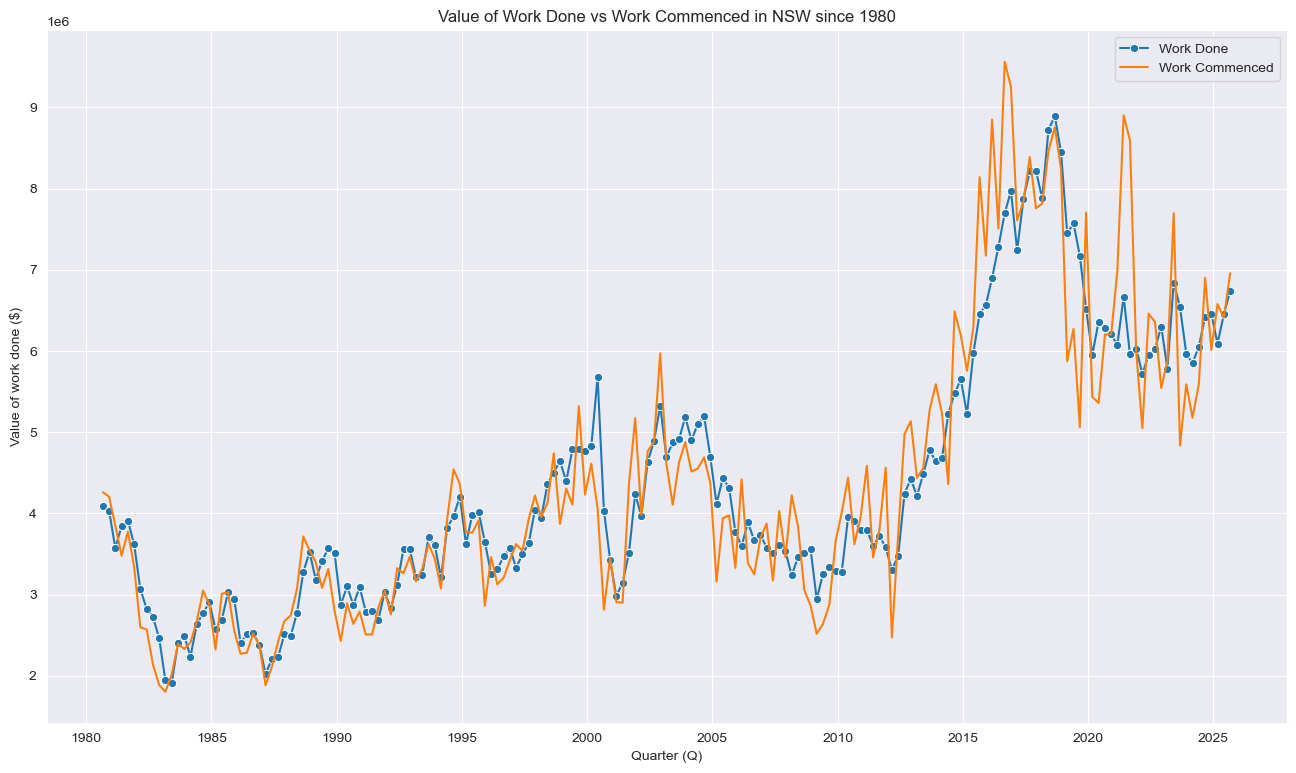

In [63]:
fig, axes = plt.subplots(figsize=(16, 9))
sns.lineplot(data=work_done, x=work_done.index, y=work_done.iloc[:, 0], ax=axes, label='Work Done', marker='o')
sns.lineplot(data=work_commenced, x=work_commenced.index, y=work_commenced.iloc[:, 0], ax=axes, label='Work Commenced')
axes.set_xlabel('Quarter (Q)')
axes.set_ylabel('Value of work done ($)')
axes.set_title('Value of Work Done vs Work Commenced in NSW since 1980')
plt.show()

## Observations
1. There is a noticeable upward trend in both the value of work done and work commenced.
2. More importantly, as of recently, the value of work commenced seems to often climb much higher than the value of work done, hinting at insufficiencies in the housing supply of NSW.
3. However, the data shows a lot of oscillatory behaviour due to the typical seasonal patterns with the housing industry such as supply being greater at certain times and lower at other times.

#### Improvements to make:
1. We must deseasonalize/adjust for seasonality for the Value of Work Commenced time series data to see the underlying trends more clearly.
2. Calculate a rolling average of both series to obtain curves that account for fluctuations and noise.

Value of Work Done already has a deseasonalized version provided by the ABS.

In [78]:
# get the data of work done adjusted for seasonality by the ABS
work_done_AS = og_work_done.copy()
work_done_AS = work_done_AS.loc[:, ['SA' in col for col in work_done_AS.columns]]
vwd_deseasonalized = work_done_AS.iloc[:, 0]
vwd_deseasonalized.name = 'VWD Deseasonalized (NSW)'
vwd_deseasonalized

Quarter
1980-09-01    3814964
1980-12-01    3799237
1981-03-01    3894618
1981-06-01    3882976
1981-09-01    3649102
               ...   
2024-09-01    6239825
2024-12-01    6461590
2025-03-01    6381595
2025-06-01    6337366
2025-09-01    6533858
Name: VWD Deseasonalized (NSW), Length: 181, dtype: int64

In [79]:
from statsmodels.tsa.seasonal import seasonal_decompose
# deseasonalize the value of work commenced data. our data goes quarterly in terms of frequency
TIME_PERIOD = 4
vwc_data = work_commenced.iloc[:, 0]
decompose_vwc = seasonal_decompose(vwc_data, period=TIME_PERIOD, model='additive')

vwc_deseasonalized = vwc_data - decompose_vwc.seasonal
vwc_deseasonalized.name = 'VWC Deseasonalized (NSW)'
vwc_deseasonalized

Quarter
1980-09-01    4.063329e+06
1980-12-01    4.116261e+06
1981-03-01    4.066058e+06
1981-06-01    3.555568e+06
1981-09-01    3.577197e+06
                  ...     
2024-09-01    6.703326e+06
2024-12-01    5.923544e+06
2025-03-01    6.791142e+06
2025-06-01    6.485161e+06
2025-09-01    6.758663e+06
Name: VWC Deseasonalized (NSW), Length: 181, dtype: float64

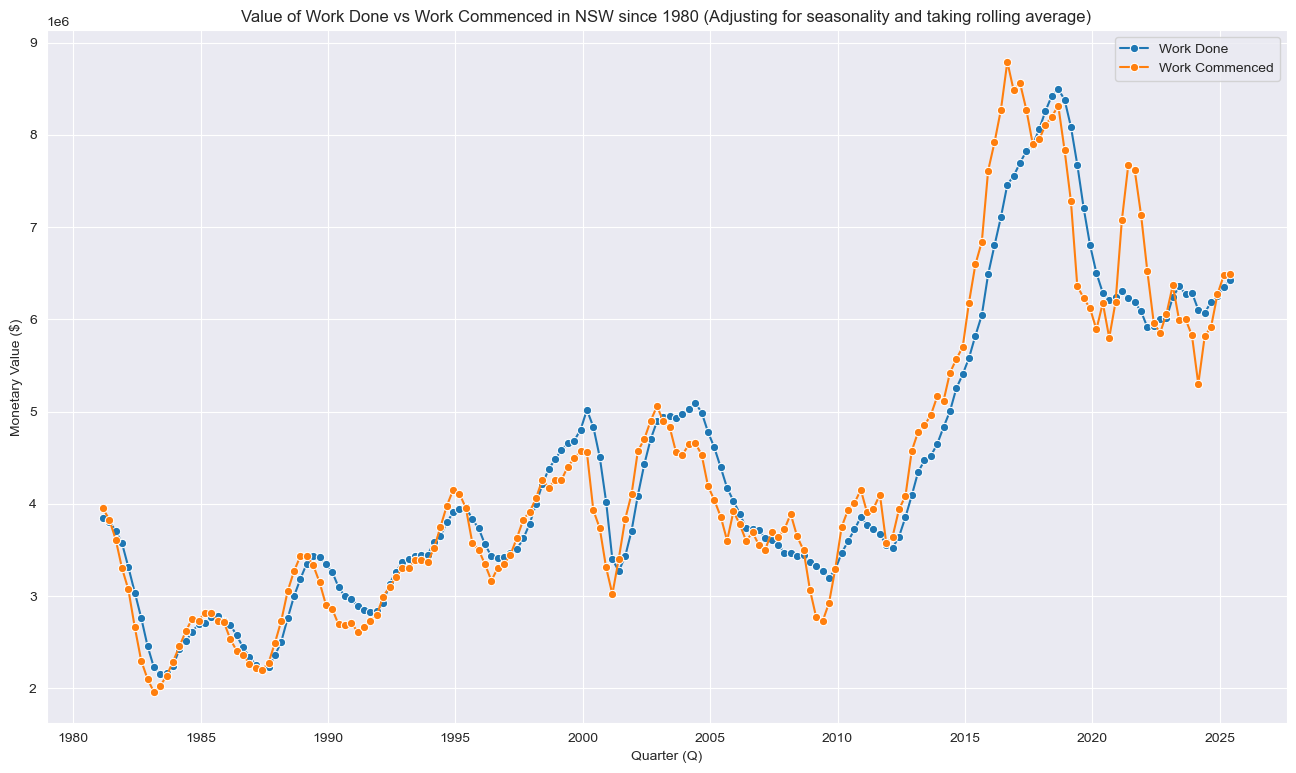

In [87]:
vwc_trend = vwc_deseasonalized.rolling(window=4, center=True).mean()
vwd_trend = vwd_deseasonalized.rolling(window=4, center=True).mean()
fig, axes = plt.subplots(figsize=(16, 9))
sns.lineplot(x=vwd_trend.index, y=vwd_trend, ax=axes, label='Work Done', marker='o')
sns.lineplot(x=vwc_trend.index, y=vwc_trend, ax=axes, label='Work Commenced', marker='o')
axes.set_xlabel('Quarter (Q)')
axes.set_ylabel('Monetary Value ($)')
axes.set_title('Value of Work Done vs Work Commenced in NSW since 1980 (Adjusting for seasonality, with rolling averages)')
plt.show()

## Observations
1. The VWD curve is lagging behind the VWC curve which makes sense because in theory, we expect there to be a gap in time between residential construction commencing and having the construction finish.
2. Overall, the value of housing has increased since 1980 with the steepest increase coming from the 2012 to 2017, where Australia experienced a housing and apartment construction boom due to factors like low interest rates and strong population growth.

**Correlation analysis with median house prices will require analysing the lagged VWD and VWC curves against the median house price curves.**